# Black Swan V4 - Date Weekly Aggregation
**Ce e nou fata de V3:**
- Agregare saptamanala in loc de zilnica
- Features recalculate cu logica corecta per tip
- Target binar identic: 1 = V-shape (>5% in 60 zile lucratoare), 0 = Non-V

## 1. Import Librarii

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)

print('Librarii incarcate.')

Librarii incarcate.


## 2. Definitia Evenimentelor

In [3]:
EVENTS = [
    {'name': 'Dotcom Crash',           'start': '2000-01-01', 'end': '2002-10-31', 'category': 'Grey Swan'},
    {'name': 'Global Financial Crisis','start': '2008-01-01', 'end': '2009-06-30', 'category': 'Grey Swan'},
    {'name': 'European Debt Crisis',   'start': '2011-04-01', 'end': '2011-12-31', 'category': 'Grey Swan'},
    {'name': 'Taper Tantrum',          'start': '2013-04-01', 'end': '2013-10-31', 'category': 'Grey Swan'},
    {'name': 'China Devaluation',      'start': '2015-06-01', 'end': '2016-02-28', 'category': 'Grey Swan'},
    {'name': 'Fed Rate Hikes 2022',    'start': '2022-01-01', 'end': '2022-12-31', 'category': 'Grey Swan'},
    {'name': 'Liberation Day Tariffs', 'start': '2025-02-01', 'end': '2025-08-01', 'category': 'Grey Swan'},
    {'name': 'COVID Crash',            'start': '2020-01-15', 'end': '2020-08-31', 'category': 'Black Swan'},
    {'name': '9/11',                   'start': '2001-07-01', 'end': '2001-12-31', 'category': 'Black Swan'},
    {'name': 'Flash Crash',            'start': '2010-04-01', 'end': '2010-08-31', 'category': 'Black Swan'},
]

print('Evenimente:', len(EVENTS))

Evenimente: 10


## 3. Descarcare Date Zilnice

Descarcam tot la rezolutie zilnica si agregam saptamanal dupa ce calculam toate features.
Asa evitam pierderea de informatie din calculul indicatorilor pe date deja agregate.

In [4]:
sp500_raw = yf.download('^GSPC', start='1999-01-01', end='2025-09-01', auto_adjust=True)
sp500_raw = sp500_raw[['Close', 'Volume']].copy()
sp500_raw.columns = ['SP500_Close', 'SP500_Volume']

vix_raw = yf.download('^VIX', start='1999-01-01', end='2025-09-01', auto_adjust=True)
vix_raw = vix_raw[['Close']].copy()
vix_raw.columns = ['VIX']

daily = sp500_raw.join(vix_raw, how='left')
daily.index = pd.to_datetime(daily.index)

print('Date zilnice descarcate:', daily.index[0].date(), '->', daily.index[-1].date())
print('Total zile:', len(daily))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Date zilnice descarcate: 1999-01-04 -> 2025-08-29
Total zile: 6706


## 4. Feature Engineering pe Date Zilnice

Calculam toti indicatorii pe rezolutie zilnica inainte de agregare.
Motivul: MA50, RSI, rolling slopes au nevoie de granularitate zilnica pentru a fi corecte.

In [5]:
df = daily.copy()

# Indicatori de trend
df['MA50']             = df['SP500_Close'].rolling(50).mean()
df['MA200']            = df['SP500_Close'].rolling(200).mean()
df['Dist_MA50']        = (df['SP500_Close'] - df['MA50'])  / df['MA50']
df['Dist_MA200']       = (df['SP500_Close'] - df['MA200']) / df['MA200']
df['Dist_52w_High']    = (df['SP500_Close'] - df['SP500_Close'].rolling(252).max()) / df['SP500_Close'].rolling(252).max()

# Volatilitate
df['Return_1d']        = df['SP500_Close'].pct_change()
df['Realized_Vol_10d'] = df['Return_1d'].rolling(10).std() * np.sqrt(252)

# RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['SP500_Close'])

# VIX
df['VIX_MA60']  = df['VIX'].rolling(60).mean()
df['VIX_Ratio'] = df['VIX'] / df['VIX_MA60']

# Slopes rolling (4 saptamani = 20 zile lucratoare)
def rolling_slope(series, window):
    slopes = [np.nan] * len(series)
    vals   = series.values
    x      = np.arange(window)
    for i in range(window - 1, len(vals)):
        y = vals[i - window + 1 : i + 1]
        if not np.any(np.isnan(y)):
            slopes[i] = np.polyfit(x, y, 1)[0]
    return pd.Series(slopes, index=series.index)

df['VIX_Trend_20d']   = rolling_slope(df['VIX'], 20)
df['SP500_Trend_20d'] = rolling_slope(df['SP500_Close'], 20)

# Distanta de la minimul local
df['Local_Min_20d']  = df['SP500_Close'].rolling(20).min()
df['Dist_Local_Min'] = (df['SP500_Close'] - df['Local_Min_20d']) / df['Local_Min_20d']

# Forward return pe 60 de zile lucratoare (identic V3)
df['Forward_Return_60d'] = df['SP500_Close'].shift(-60) / df['SP500_Close'] - 1
df['label_daily']        = (df['Forward_Return_60d'] > 0.05).astype(float)

print('Features zilnice calculate.')

Features zilnice calculate.


## 5. Agregare Saptamanala

Fiecare feature are logica proprie de agregare:
- **Close, MA, RSI, Dist:** ultima zi a saptamanii (vineri) - sunt indicatori de pret
- **VIX:** media saptamanii - nivelul de frica trebuie mediat
- **Return:** return de la vineri la vineri - nu media retururilor zilnice
- **Volume:** suma saptamanii
- **Realized_Vol:** media saptamanii
- **Label:** modul saptamanii (clasa majoritara din cele 5 zile)

In [6]:
# Definim regulile de agregare per coloana
agg_rules = {
    # Pret: ultima valoare a saptamanii
    'SP500_Close'   : 'last',
    'MA50'          : 'last',
    'MA200'         : 'last',
    'Dist_MA50'     : 'last',
    'Dist_MA200'    : 'last',
    'Dist_52w_High' : 'last',
    'RSI'           : 'last',
    'Dist_Local_Min': 'last',

    # VIX: media saptamanii
    'VIX'           : 'mean',
    'VIX_Ratio'     : 'mean',
    'VIX_Trend_20d' : 'mean',

    # Trend SP500: ultima valoare
    'SP500_Trend_20d': 'last',

    # Volatilitate: media saptamanii
    'Realized_Vol_10d': 'mean',

    # Volum: suma
    'SP500_Volume'  : 'sum',

    # Label: moda (clasa majoritara)
    'label_daily'   : lambda x: x.mode()[0] if len(x) > 0 else np.nan
}

# Agregare la nivel de saptamana (W-FRI = sfarsit de saptamana vineri)
weekly = df.resample('W-FRI').agg(agg_rules)

# Return saptamanal: de la un close de vineri la urmatorul
weekly['Return_1w'] = weekly['SP500_Close'].pct_change()

# Return pe 4 saptamani
weekly['Return_4w'] = weekly['SP500_Close'].pct_change(4)

# Volume ratio saptamanal
weekly['Volume_Ratio'] = weekly['SP500_Volume'] / weekly['SP500_Volume'].rolling(8).mean()

# Redenumim label
weekly['label'] = weekly['label_daily'].astype(int)

weekly.dropna(subset=['Return_1w', 'label'], inplace=True)

print('Date saptamanale:')
print('Total saptamani:', len(weekly))
print('Perioada:', weekly.index[0].date(), '->', weekly.index[-1].date())
print('\nSample agregat:')
weekly[['SP500_Close', 'VIX', 'Return_1w', 'RSI', 'label']].tail(5)

Date saptamanale:
Total saptamani: 1390
Perioada: 1999-01-15 -> 2025-08-29

Sample agregat:


,SP500_Close,VIX,Return_1w,RSI,label
Date,,,,,
2025-08-01,6238.009766,16.717999,-0.023578,45.281232,0
2025-08-08,6389.450195,16.772000,0.024277,59.134182,0
2025-08-15,6449.799805,15.078000,0.009445,55.947655,0
2025-08-22,6466.910156,15.414000,0.002653,65.659804,0
2025-08-29,6460.259766,14.810000,-0.001028,60.287184,0


## 6. Constructie Dataset cu Ferestre per Eveniment

In [7]:
feature_cols = [
    # Pret si trend
    'Return_1w', 'Return_4w', 'Dist_MA50', 'Dist_MA200',
    'Dist_52w_High', 'Dist_Local_Min',
    # VIX si frica
    'VIX', 'VIX_Ratio', 'VIX_Trend_20d',
    # Volatilitate si volum
    'Realized_Vol_10d', 'Volume_Ratio',
    # Momentum
    'RSI', 'SP500_Trend_20d',
    # Faza crizei
    'Phase'
]

all_windows = []

for event in EVENTS:
    mask   = (weekly.index >= event['start']) & (weekly.index <= event['end'])
    window = weekly.loc[mask].copy()

    if len(window) == 0:
        print('ATENTIE: Nu s-au gasit date pentru', event['name'])
        continue

    n = len(window)
    # Phase in saptamani: early = primele 6 saptamani, mid = 7-18, late = 19+
    phases = [1 if i <= 6 else (2 if i <= 18 else 3) for i in range(n)]
    window['Phase']        = phases
    window['event_name']   = event['name']
    window['category']     = event['category']
    window['week_relative'] = range(n)

    all_windows.append(window)
    print(event['name'].ljust(30), ':', n, 'saptamani')

dataset = pd.concat(all_windows)
dataset = dataset.dropna(subset=feature_cols + ['label'])

print('\nDataset final:', len(dataset), 'saptamani')
print('\nDistributia labelurilor:')
counts = dataset['label'].value_counts()
print('  Non-V (0):', counts.get(0, 0), '(' + str(round(counts.get(0,0)/len(dataset)*100, 1)) + '%)')
print('  V-shape (1):', counts.get(1, 0), '(' + str(round(counts.get(1,0)/len(dataset)*100, 1)) + '%)')
print('\nDistributie per eveniment:')
pivot = dataset.groupby(['event_name', 'label']).size().unstack(fill_value=0)
pivot.columns = ['Non-V (0)', 'V-shape (1)']
pivot['% V-shape'] = (pivot['V-shape (1)'] / (pivot['Non-V (0)'] + pivot['V-shape (1)']) * 100).round(1)
print(pivot)

Dotcom Crash                   : 147 saptamani
Global Financial Crisis        : 78 saptamani
European Debt Crisis           : 40 saptamani
Taper Tantrum                  : 30 saptamani
China Devaluation              : 39 saptamani
Fed Rate Hikes 2022            : 52 saptamani
Liberation Day Tariffs         : 26 saptamani
COVID Crash                    : 33 saptamani
9/11                           : 26 saptamani
Flash Crash                    : 22 saptamani

Dataset final: 493 saptamani

Distributia labelurilor:
  Non-V (0): 358 (72.6%)
  V-shape (1): 135 (27.4%)

Distributie per eveniment:
                         Non-V (0)  V-shape (1)  % V-shape
event_name                                                
9/11                            21            5       19.2
COVID Crash                     11           22       66.7
China Devaluation               28           11       28.2
Dotcom Crash                   130           17       11.6
European Debt Crisis            25           15  

## 7. Train / Test Split

In [8]:
TRAIN_EVENTS = [
    'Global Financial Crisis', 'European Debt Crisis',
    'Taper Tantrum', 'China Devaluation', '9/11', 'Flash Crash'
]
TEST_EVENTS = [
    'Fed Rate Hikes 2022', 'COVID Crash', 'Liberation Day Tariffs'
]

# Dotcom spart: ultimele 40 saptamani -> test (echivalent ~200 zile)
dotcom_all   = dataset[dataset['event_name'] == 'Dotcom Crash']
dotcom_train = dotcom_all.iloc[:-40]
dotcom_test  = dotcom_all.iloc[-40:]

train_df = pd.concat([dotcom_train, dataset[dataset['event_name'].isin(TRAIN_EVENTS)]])
test_df  = pd.concat([dotcom_test,  dataset[dataset['event_name'].isin(TEST_EVENTS)]])

train_df = train_df.dropna(subset=feature_cols)
test_df  = test_df.dropna(subset=feature_cols)

print('Train:', len(train_df), 'saptamani')
print('Test: ', len(test_df),  'saptamani')

for name, split in [('Train', train_df), ('Test', test_df)]:
    c = split['label'].value_counts()
    print('\nDistributie', name + ':')
    print('  Non-V (0):', c.get(0, 0))
    print('  V-shape (1):', c.get(1, 0))

Train: 342 saptamani
Test:  151 saptamani

Distributie Train:
  Non-V (0): 254
  V-shape (1): 88

Distributie Test:
  Non-V (0): 104
  V-shape (1): 47


## 8. Vizualizare Labeluri Saptamanale

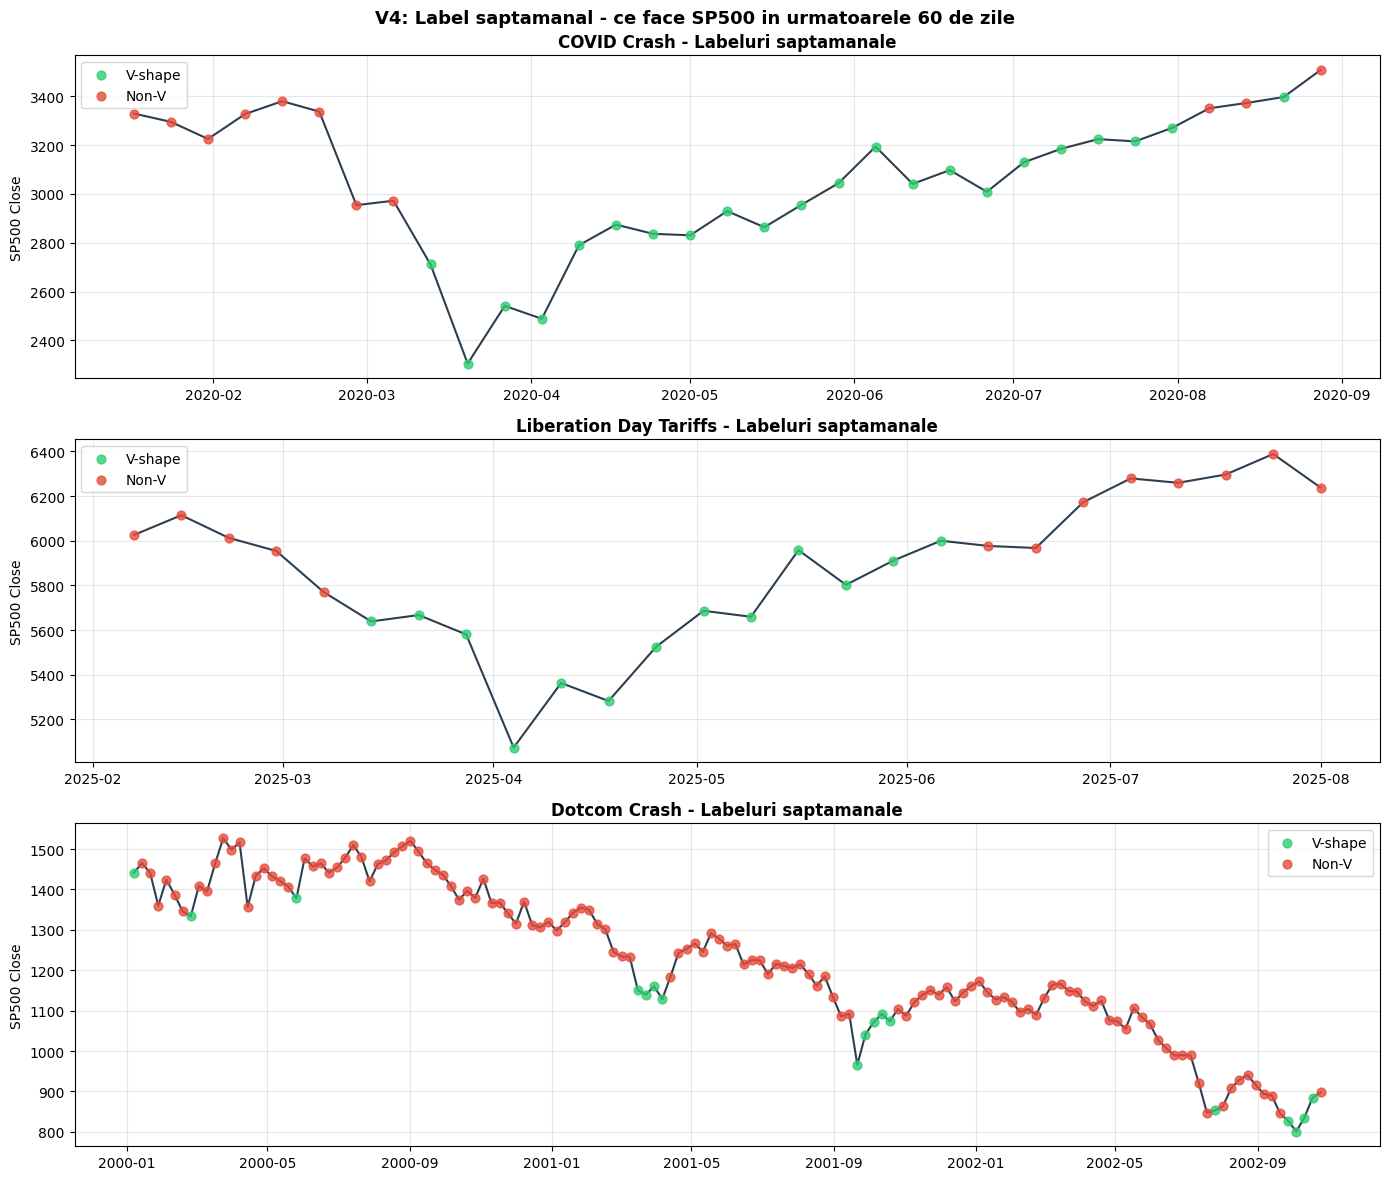

Salvat: plots/v4_weekly_labels.png


In [9]:
events_to_plot = ['COVID Crash', 'Liberation Day Tariffs', 'Dotcom Crash']
colors_map     = {1: '#2ecc71', 0: '#e74c3c'}
labels_map     = {1: 'V-shape', 0: 'Non-V'}

fig, axes = plt.subplots(len(events_to_plot), 1, figsize=(14, 4 * len(events_to_plot)))

for ax, event_name in zip(axes, events_to_plot):
    ev     = dataset[dataset['event_name'] == event_name]
    prices = ev['SP500_Close']

    ax.plot(prices.index, prices.values, color='#2c3e50', linewidth=1.5, zorder=3)

    for lbl, color in colors_map.items():
        mask = ev['label'] == lbl
        if mask.any():
            ax.scatter(
                ev.index[mask], prices[mask],
                color=color, s=40, alpha=0.8,
                label=labels_map[lbl], zorder=4
            )

    ax.set_title(event_name + ' - Labeluri saptamanale', fontsize=12, fontweight='bold')
    ax.set_ylabel('SP500 Close')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('V4: Label saptamanal - ce face SP500 in urmatoarele 60 de zile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/v4_weekly_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvat: plots/v4_weekly_labels.png')

## 9. Salvare Dataset

In [10]:
dataset.to_csv('v4_dataset.csv')
train_df.to_csv('v4_train.csv')
test_df.to_csv('v4_test.csv')

with open('v4_feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print('Fisiere salvate:')
print('  v4_dataset.csv ->', len(dataset), 'saptamani')
print('  v4_train.csv   ->', len(train_df), 'saptamani')
print('  v4_test.csv    ->', len(test_df), 'saptamani')
print('  v4_feature_cols.json')
print('\nGata pentru v4_modeling.ipynb')

Fisiere salvate:
  v4_dataset.csv -> 493 saptamani
  v4_train.csv   -> 342 saptamani
  v4_test.csv    -> 151 saptamani
  v4_feature_cols.json

Gata pentru v4_modeling.ipynb
